---
**Name : Aashoday S Surwade**\
**Roll No : 24AI126**\
**Class : SE-B AIML**\
**Course : FML**\
**FML Assignment 3**

---

**Problem Statement** :

Implement assignment based on naive bayes classifier and
evaluate the performance (confusion matrix, accuracy, precision,
recall, F-1 Score),

*Case Study* : SMS Spam Detection: A telecom company wants to
filter out spam SMS messages before delivering them to users.
The goal is to build a machine learning model that can classify
SMS messages as spam or ham (not spam) using a dataset of
labeled messages.

---

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Download and Load dataset
# https://archive.ics.uci.edu/dataset/228/sms+spam+collection

data = pd.read_csv("/home/ashx/ML/Projects/fml-lab/data/SMSSpamCollection", sep="\t", header=None)
data.columns = ["label", "message"]
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Map labels 0 : ham , 1: spam
data["label"] = data["label"].map({"ham": 0, "spam": 1})
print(data["label"].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


In [4]:
# Convert text messages into feature vectors
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(data["message"])
y = data["label"]

print("Feature matrix shape: ", X.shape)

Feature matrix shape:  (5572, 8713)


In [5]:
# Split data in 80-20 training, testing sets 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


In [6]:
# Instantiate and fit model class 
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [7]:
# Make predictions on trained model
y_pred = model.predict(X_test)

In [9]:
# Evaluate predictions
cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nAccuracy Score:", accuracy)
print("Precision Score:", precision)
print("Recall Score:", recall)
print("F1 Score:", f1)

Confusion Matrix:
 [[955  11]
 [  8 141]]

Accuracy Score: 0.9829596412556054
Precision Score: 0.9276315789473685
Recall Score: 0.9463087248322147
F1 Score: 0.9368770764119602


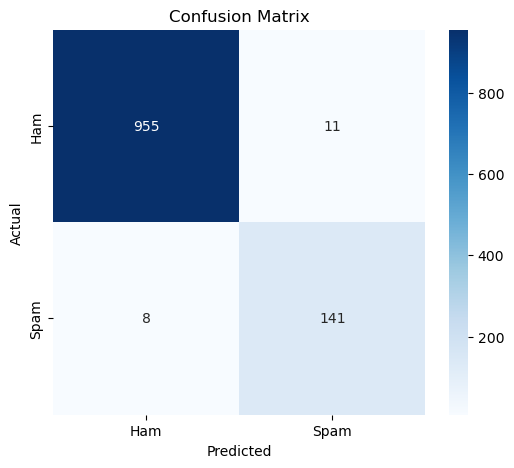

In [10]:
# Visulaize confusion matrix in form of a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


---
### Conclusion

In this assignment, a Multinomial Naive Bayes classifier was implemented to classify SMS messages as spam or ham. Text data was converted into numerical features using the Bag-of-Words technique, and the model was trained and evaluated using standard performance metrics.

The classifier achieved high accuracy (98.3%) along with strong precision, recall, and F1-score, indicating effective spam detection with minimal misclassification. The results demonstrate that Naive Bayes is a simple yet powerful algorithm for text classification tasks such as SMS spam filtering.

---